# Extreme learning machine model for neonate clinical indicators

## 1. Import libraries

In [49]:
import pandas as pd
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, auc
from sklearn.inspection import permutation_importance
import shap
import joblib


## 2. Load the dataset

In [ ]:
df = pd.read_csv('../../clinical_data/neonatal_processed.csv')
df.head()

,gestational_age_weeks,birth_weight_g,head_circumference_cm,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,primary_outcome
0,38.2,2730,37.0,0,9,10,36.7,147,48,96,0
1,39.8,2260,34.8,0,5,9,36.7,125,43,97,0
2,37.1,3030,39.4,0,9,9,36.4,120,47,97,0
3,39.7,3130,18.1,0,8,10,36.8,143,54,96,0
4,40.5,2870,34.1,0,8,7,37.2,108,46,97,0


## 3. Separate features and target variable

In [ ]:
x = df.drop("primary_outcome", axis=1)
y = df["primary_outcome"]

## 4. Scale features

In [ ]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

## 5. Train-Test Split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

## 6. Initialize ELM parameters

In [ ]:
input_size = x_train.shape[1] #number of features
hidden_neurons = 950 #number of neurons in hidden layer
output_size = 1 #binary classification

#Initialize weights
w = np.random.rand(input_size, hidden_neurons)
b = np.random.rand(output_size, hidden_neurons)

## 7. Define activation function

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

## 8. Compute hidden layer output

In [ ]:
h_train = sigmoid(np.dot(x_train, w) + b)

## 9. Compute output weights (beta)

In [ ]:
beta = np.dot(np.linalg.pinv(h_train), y_train)

## 10. Predict on test set

In [ ]:
h_test = sigmoid(np.dot(x_test, w) + b)
y_pred_prob = np.dot(h_test, beta)
y_pred = (y_pred_prob >= 0.35).astype(int)

## 11. Evaluate performance

In [ ]:
#Accuracy evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"ELM Model Accuracy: {accuracy:.4f}")

#Precision, Recall, F1-Score
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

#PR_AUC evaluation
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

ELM Model Accuracy: 0.9832
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7296
           1       0.69      0.69      0.69       204

    accuracy                           0.98      7500
   macro avg       0.84      0.84      0.84      7500
weighted avg       0.98      0.98      0.98      7500

Precision-Recall AUC: 0.7610


## 12. Evaluation visuals

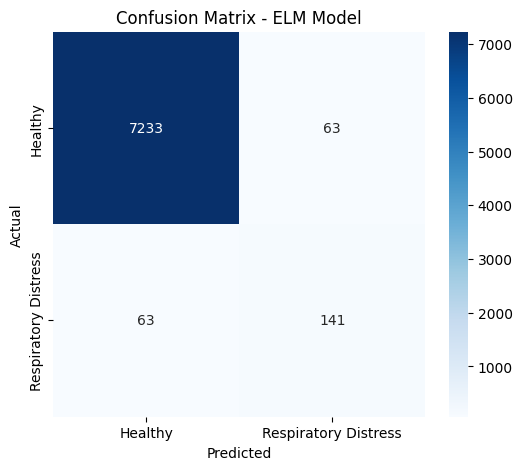

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Healthy', 'Respiratory Distress']
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - ELM Model')
plt.show()

## 13. Explainability

Top 10 Most Important Features (by correlation with target):
10. spo2_percent                   - 0.432068
 9. respiratory_rate_bpm           - 0.406376
 7. temperature_c                  - 0.290816
 1. gestational_age_weeks          - 0.285778
 2. birth_weight_g                 - 0.228191
 5. apgar_1min                     - 0.203522
 6. apgar_5min                     - 0.180081
 3. head_circumference_cm          - 0.049660
 4. delivery_mode                  - 0.042924
 8. heart_rate_bpm                 - 0.012181


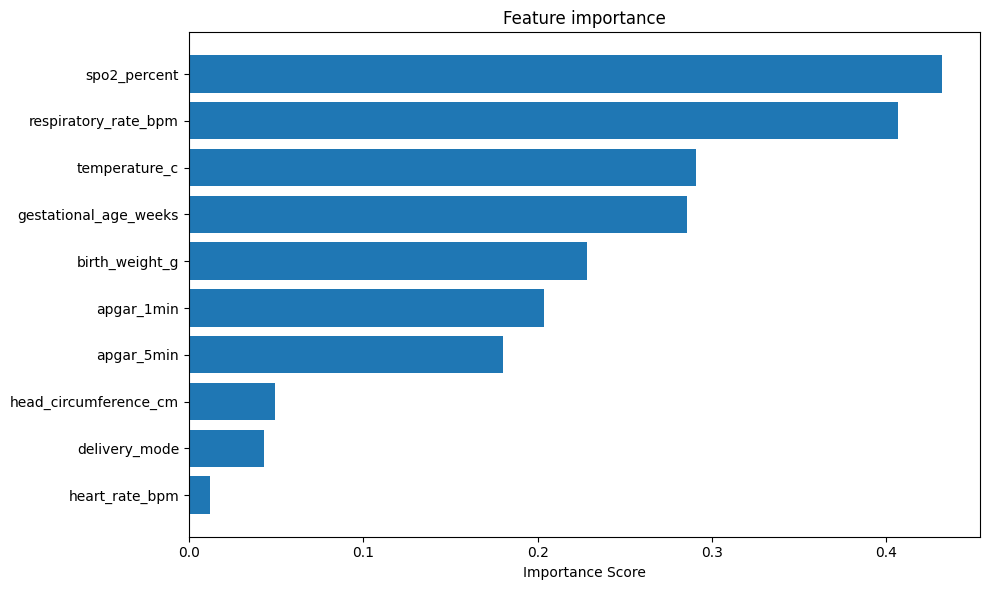

In [ ]:
# Feature importance using correlation with target variable
# Get feature names from the original dataframe (excluding target)
feature_names = df.drop("primary_outcome", axis=1).columns.tolist()

# Create a dataframe with scaled features and target
combined_df = pd.DataFrame(x, columns=feature_names)
combined_df['target'] = y.values

# Calculate correlation of each feature with the target
correlations = combined_df.corr()['target'].drop('target').abs()

# Create a dataframe for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': correlations.values
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features (by correlation with target):")
print("=" * 50)
for idx, row in importance_df.head(10).iterrows():
    print(f"{idx+1:2d}. {row['Feature']:30s} - {row['Importance']:.6f}")

plt.figure(figsize=(10, 6))
plt.barh(importance_df.head(10)['Feature'][::-1], importance_df.head(10)['Importance'][::-1])
plt.xlabel('Importance Score')
plt.title('Feature importance')
plt.tight_layout()
plt.show()

Computing SHAP values... This may take a moment.


  0%|          | 0/100 [00:00<?, ?it/s]

SHAP values computed for 100 samples


C:\Users\mable\AppData\Local\Temp\ipykernel_35680\2728089738.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_test[:100], feature_names=feature_names, plot_type="bar", show=False)


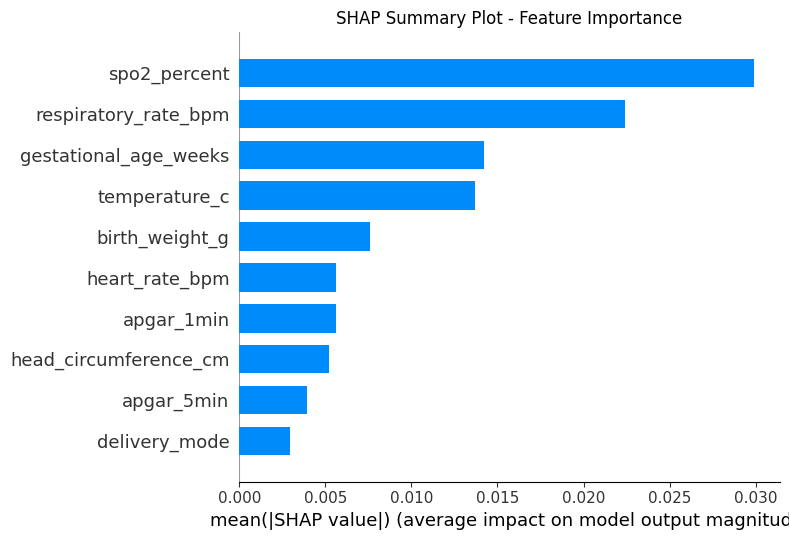

C:\Users\mable\AppData\Local\Temp\ipykernel_35680\2728089738.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_test[:100], feature_names=feature_names, show=False)


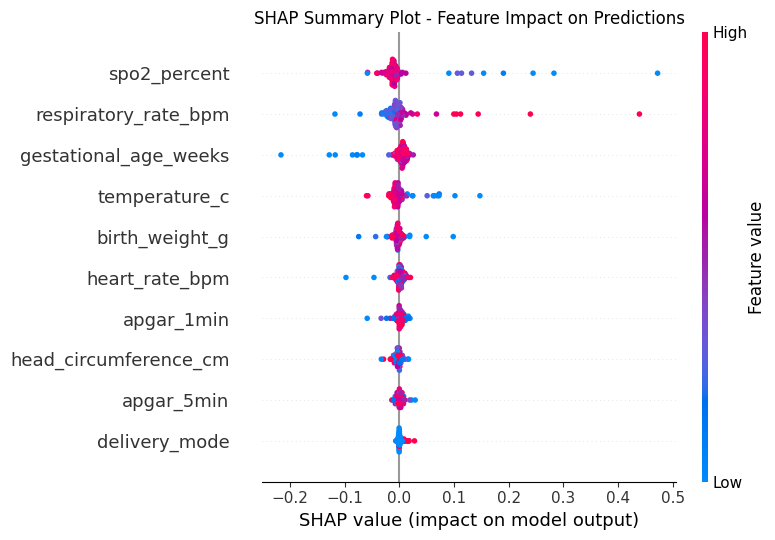


Top 10 Features by Mean Absolute SHAP Value:
 1. spo2_percent                   - 0.029914
 2. respiratory_rate_bpm           - 0.022428
 3. gestational_age_weeks          - 0.014196
 4. temperature_c                  - 0.013707
 5. birth_weight_g                 - 0.007616
 6. heart_rate_bpm                 - 0.005611
 7. apgar_1min                     - 0.005599
 8. head_circumference_cm          - 0.005205
 9. apgar_5min                     - 0.003966
10. delivery_mode                  - 0.002934


In [ ]:
# SHAP Values for Model Explainability
# Define prediction function for SHAP
def elm_predict(X):
    h = sigmoid(np.dot(X, w) + b)
    y_prob = np.dot(h, beta)
    return y_prob.reshape(-1)

# Create SHAP explainer using KernelExplainer (model-agnostic)
print("Computing SHAP values... This may take a moment.")
explainer = shap.KernelExplainer(elm_predict, shap.sample(x_test, min(50, len(x_test))))
shap_values = explainer.shap_values(x_test[:100])  # Compute for first 100 test samples

print(f"SHAP values computed for {len(shap_values)} samples")

# Summary plot (bar plot of mean absolute SHAP values)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, x_test[:100], feature_names=feature_names, plot_type="bar", show=False)
plt.title('SHAP Summary Plot - Feature Importance')
plt.tight_layout()
plt.show()

# Summary plot (beeswarm/scatter plot showing feature impact)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, x_test[:100], feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Feature Impact on Predictions')
plt.tight_layout()
plt.show()

# Print top 10 features by mean absolute SHAP value
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[-10:][::-1]

print("\nTop 10 Features by Mean Absolute SHAP Value:")
print("=" * 50)
for rank, idx in enumerate(top_indices, 1):
    print(f"{rank:2d}. {feature_names[idx]:30s} - {mean_abs_shap[idx]:.6f}")

In [51]:
elm_model_data = {
    'w': w,
    'beta': beta,
    'b': b,
    'scaler': scaler,
    'input_size': input_size,
    'hidden_neurons': hidden_neurons,
    'output_size': output_size,
    'feature_names': feature_names,
    'accuracy': accuracy
}
joblib.dump(elm_model_data, "elm_model.pkl")
print("✅ ELM model saved to elm_model.pkl")

✅ ELM model saved to elm_model.pkl
